In [1]:
from google.colab import files
uploaded = files.upload()

Saving 1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv to 1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv


In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df = df.drop(columns=["Unnamed: 0"])

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv")
df = df.drop(columns=["Unnamed: 0"])

In [6]:
df.head(15)

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


In [7]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 1.8 MB


illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64


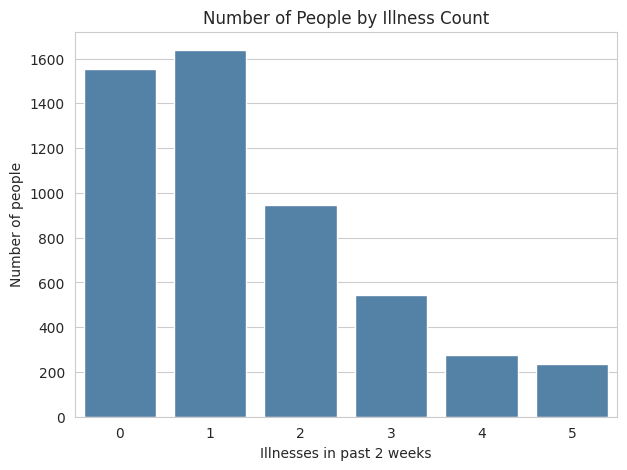

In [8]:
illness_counts = df["illness"].value_counts().sort_index()
print(illness_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=illness_counts.index, y=illness_counts.values, color="steelblue")
plt.title("Number of People by Illness Count")
plt.xlabel("Illnesses in past 2 weeks")
plt.ylabel("Number of people")
plt.show()

Max income: 1.5
Min income: 0.0
Median income: 0.55


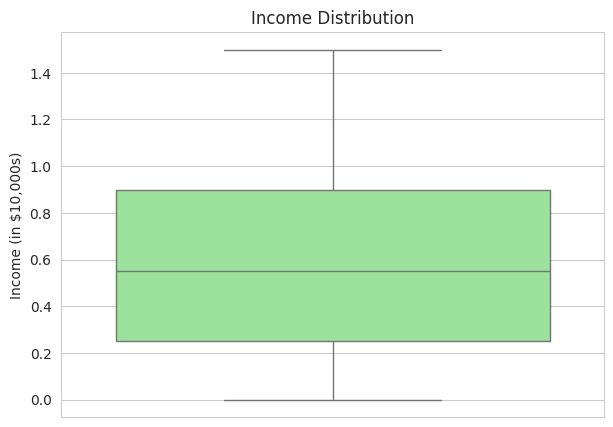

In [9]:
print("Max income:", df["income"].max())
print("Min income:", df["income"].min())
print("Median income:", df["income"].median())

plt.figure(figsize=(7, 5))
sns.boxplot(y=df["income"], color="lightgreen")
plt.title("Income Distribution")
plt.ylabel("Income (in $10,000s)")
plt.show()

gender
female    2636
male      1837
Name: reduced, dtype: int64


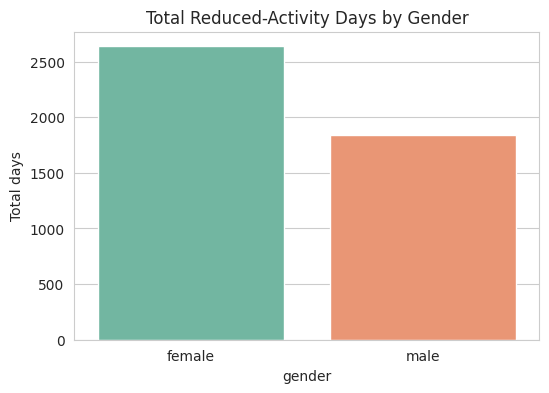

In [10]:
reduced_by_gender = df.groupby("gender")["reduced"].sum()
print(reduced_by_gender)

plt.figure(figsize=(6, 4))
sns.barplot(x=reduced_by_gender.index, y=reduced_by_gender.values, hue=reduced_by_gender.index, palette="Set2", legend=False)
plt.title("Total Reduced-Activity Days by Gender")
plt.ylabel("Total days")
plt.show()

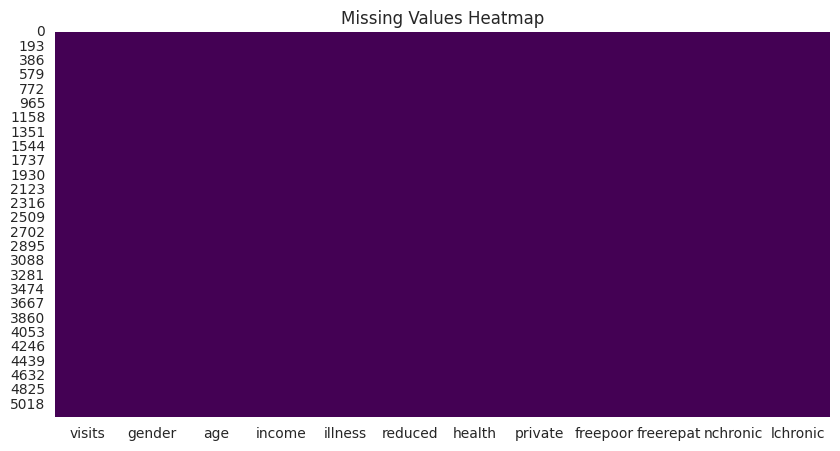

In [11]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

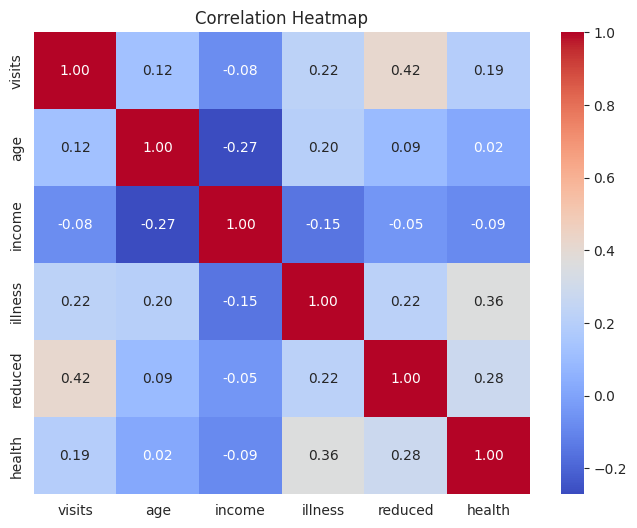

In [12]:
numeric_df = df[["visits", "age", "income", "illness", "reduced", "health"]]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

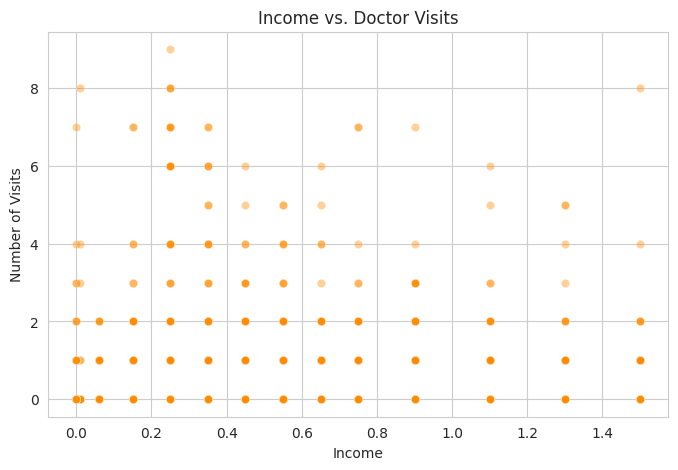

Correlation: -0.07683982934758851


In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="income", y="visits", data=df, alpha=0.4, color="darkorange")
plt.title("Income vs. Doctor Visits")
plt.xlabel("Income")
plt.ylabel("Number of Visits")
plt.show()

print("Correlation:", df["income"].corr(df["visits"]))

gender
female    2023
male      1613
Name: count, dtype: int64


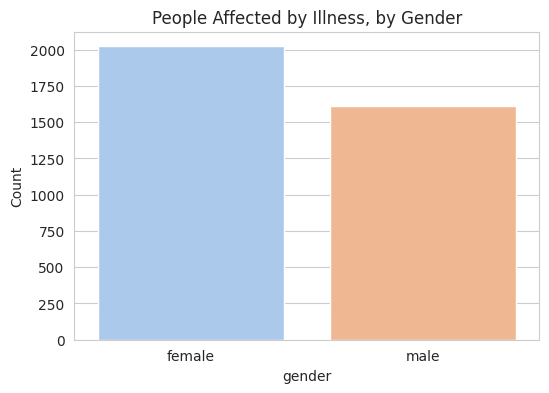

In [14]:
affected = df[df["illness"] > 0]
gender_affected = affected["gender"].value_counts()
print(gender_affected)

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_affected.index, y=gender_affected.values, hue=gender_affected.index, palette="pastel", legend=False)
plt.title("People Affected by Illness, by Gender")
plt.ylabel("Count")
plt.show()

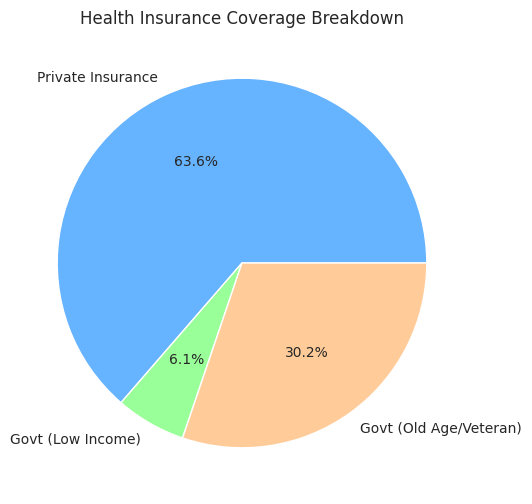

In [15]:
insurance_data = {
    "Private Insurance": (df["private"] == "yes").mean() * 100,
    "Govt (Low Income)": (df["freepoor"] == "yes").mean() * 100,
    "Govt (Old Age/Veteran)": (df["freerepat"] == "yes").mean() * 100,
}

plt.figure(figsize=(6, 6))
plt.pie(insurance_data.values(), labels=insurance_data.keys(), autopct="%1.1f%%", colors=["#66b3ff", "#99ff99", "#ffcc99"])
plt.title("Health Insurance Coverage Breakdown")
plt.show()

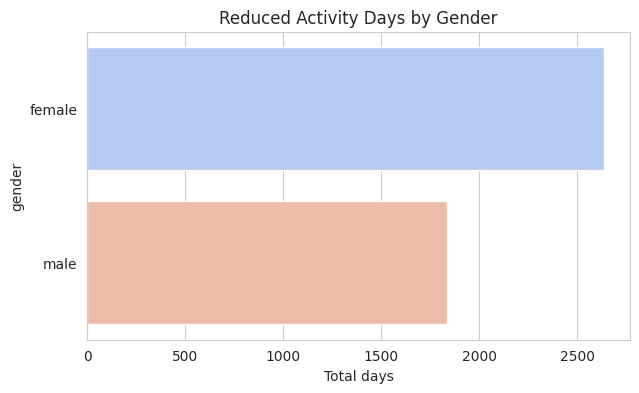

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(x=reduced_by_gender.values, y=reduced_by_gender.index, hue=reduced_by_gender.index, palette="coolwarm", orient="h", legend=False)
plt.title("Reduced Activity Days by Gender")
plt.xlabel("Total days")
plt.show()

lchronic
no     0.261941
yes    0.603306
Name: visits, dtype: float64


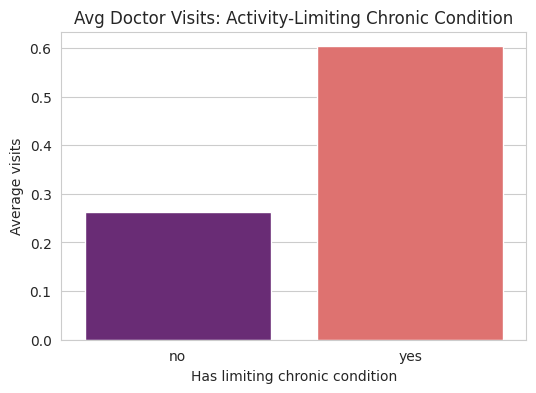

In [17]:
chronic_visits = df.groupby("lchronic")["visits"].mean()
print(chronic_visits)

plt.figure(figsize=(6, 4))
sns.barplot(x=chronic_visits.index, y=chronic_visits.values, hue=chronic_visits.index, palette="magma", legend=False)
plt.title("Avg Doctor Visits: Activity-Limiting Chronic Condition")
plt.xlabel("Has limiting chronic condition")
plt.ylabel("Average visits")
plt.show()

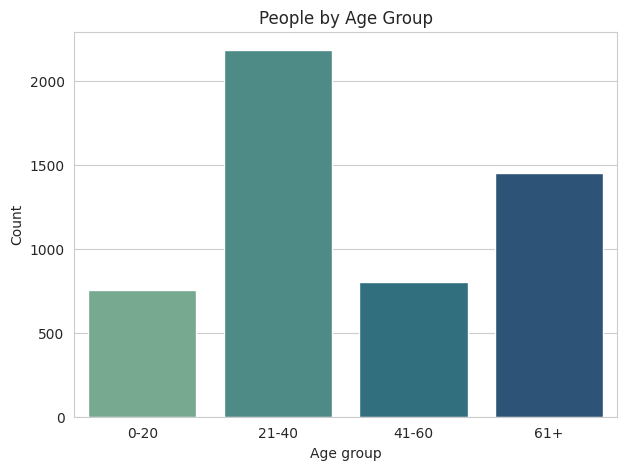

In [18]:
df["age_years"] = df["age"] * 100
df["age_group"] = pd.cut(df["age_years"], bins=[0, 20, 40, 60, 100], labels=["0-20", "21-40", "41-60", "61+"])

plt.figure(figsize=(7, 5))
sns.countplot(x="age_group", data=df, hue="age_group", palette="crest", legend=False)
plt.title("People by Age Group")
plt.xlabel("Age group")
plt.ylabel("Count")
plt.show()

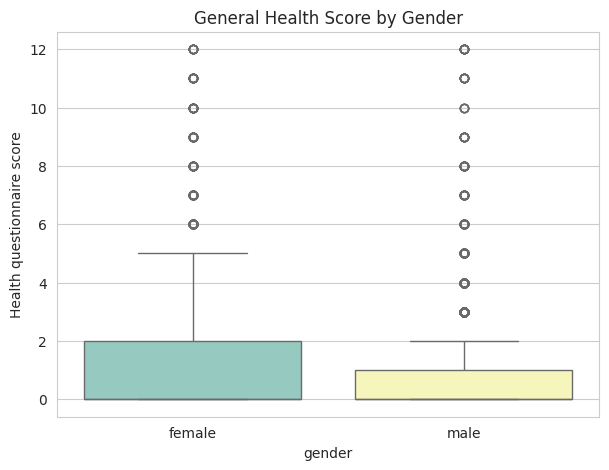

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="gender", y="health", data=df, hue="gender", palette="Set3", legend=False)
plt.title("General Health Score by Gender")
plt.ylabel("Health questionnaire score")
plt.show()